# Reaction Cross Section — From Neutron and Proton Densities

This notebook shows how to compute reaction cross sections using the Glauber model, neutron $\rho_n(r)$ and proton densities $\rho_p(r)$.
It loads neutron $\rho_n(r)$ and proton densities $\rho_p(r)$, converts them to an impact-parameter form $\rho_n(b)$ and $\rho_p(b)$, constructs three profile function ($\Gamma_{nn}$, $\Gamma_{np}$, $\Gamma_{pp}$), and evaluates reaction cross sections using the Optical Limit Approximation (OLA) and the Modified Optical Limit (MOL).  (see textbook as  Structure and Reactions of Light Exotic Nuclei by Y. Suzuki, K. Yabana, R. G. Lovas, and K. Varga)

Notes: units are used consistently where appropriate: radius r and impact parameter b in fm; neutron and proton densities $\rho_n(r)$ and $\rho_p(r)$ in $\mathrm{fm}^{-3} $ and for $\rho_n(b)$ and $\rho_p(b)$ in $\mathrm{fm}^{-2}$; cross sections are reported in millibarns (mb).


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ERICCA as ERICCa


## 1) Densities for $^{12}\mathrm{C}$ and $^{42}\mathrm{Ca}$

### Load external density 


Load example $^{12}\mathrm{C}$ and and $^{42}\mathrm{Ca}$ proton and neutron densities that were precomputed using Fayans EDF. The files contain radial meshes r [fm] ande densities  $\rho_p(r)$ and $\rho_n(r)$ [$\mathrm{fm}^{-3} $]. We use one sample (first row) for the demonstration.

Loaded proton/neutron densities:
$^{12}$C p.shape = (500, 31) n.shape = (500, 31)
$^{42}$Ca p.shape = (500, 36) n.shape = (500, 36)


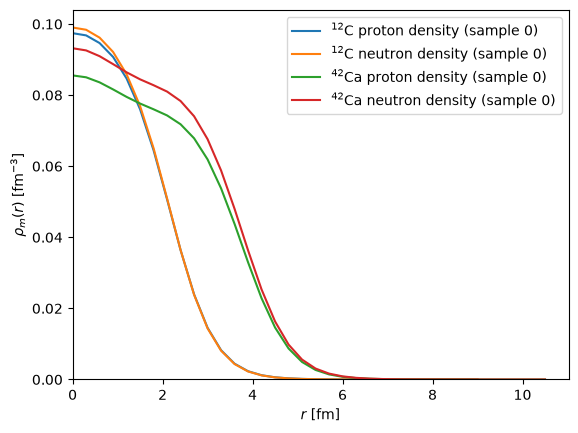

In [3]:
# $^{12}$C proton and neutron densities
C_p = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-prot.txt", unpack=True)
C_n = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-neut.txt", unpack=True)
r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack=True)

# $^{42}$Ca proton and neutron densities (example target)
Ca_p = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-prot.txt", unpack=True)
Ca_n = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-neut.txt", unpack=True)
Ca_r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/42Ca_radius.txt", unpack=True)

print('Loaded proton/neutron densities:')
print('$^{12}$C p.shape =', C_p.shape, 'n.shape =', C_n.shape)
print('$^{42}$Ca p.shape =', Ca_p.shape, 'n.shape =', Ca_n.shape)


plt.plot(r_mesh[0], C_p[0], color='C0', label=r'$^{12}$C proton density (sample 0)')
plt.plot(r_mesh[0], C_n[0], color='C1', label=r'$^{12}$C neutron density (sample 0)')
plt.plot(Ca_r_mesh[0], Ca_p[0], color='C2', label=r'$^{42}$Ca proton density (sample 0)')
plt.plot(Ca_r_mesh[0], Ca_n[0], color='C3', label=r'$^{42}$Ca neutron density (sample 0)')
plt.xlabel(r'$r$ [fm]')
plt.ylabel(r'$\rho_m(r)$ [fm$^{-3}$]')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.show()


## 2) Profile Functions $\Gamma_{pp}(b)$, $\Gamma_{pn}(b)$, $\Gamma_{nn}(b)$

The **profile functions** $\Gamma_{pp}(b)$, $\Gamma_{pn}(b)$, and $\Gamma_{nn}(b)$ describe the effective interaction strength as a function of the **impact parameter** $b$ for:
- Proton-proton ($pp$)
- Proton-neutron ($pn$)
- Neutron-neutron ($nn$) interactions

In ERICCa, the `ProfileFunction` class implements these with the analytical form:

$$
\Gamma(b) = \frac{(1 - i \alpha)}{4 \pi \beta} \cdot \sigma_{NN} \cdot \exp\left(-\frac{b^2}{2 \beta}\right)
$$

with $\alpha$ dimensionless, $\beta$ in $\mathrm{fm}^2$ and $\sigma_{NN}$ the nucleon-nucleon cross section in $\mathrm{fm}^2$.


Parameters from Ref. [Andy fills this] are built in for laboratory energies $E$  from 40 MeV to 1000 MeV. The implementation assumes $\Gamma_{nn}(b) = \Gamma_{pp}(b)$

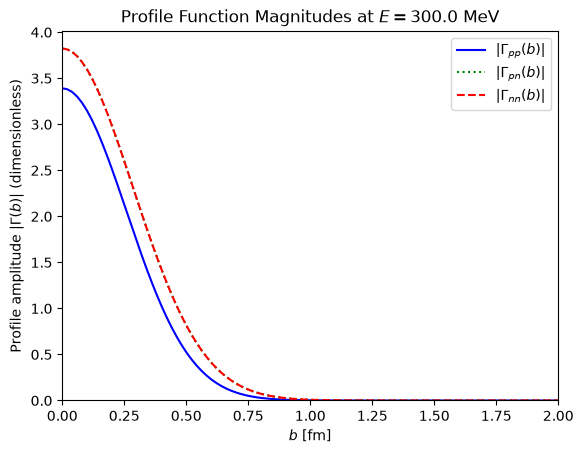

In [4]:
# --- Initialize Profile Function at E = 300 MeV ---
E = 300.0  # Laboratory energy [MeV]

# Create profile function for neutron-proton interactions
profile_np = ERICCa.ProfileFunction(model_type='np', E=E)

# --- Generate impact-parameter mesh ---
b_mesh = np.linspace(0.0, 6.0, 300)  # b in [fm]

# --- Compute profile functions for different interaction channels ---
Gamma_pp = profile_np.Gamma_pp(b_mesh)  # Proton-proton profile Γ_pp(b)
Gamma_pn = profile_np.Gamma_pn(b_mesh)  # Proton-neutron profile Γ_pn(b)
Gamma_nn = profile_np.Gamma_pn(b_mesh) # Neutron-neutron  profile Γ_nn(b)

# --- Plot profile function magnitudes ---
plt.plot(b_mesh, np.abs(Gamma_pp), label=r'$|\Gamma_{pp}(b)|$', linestyle='-', color='blue')
plt.plot(b_mesh, np.abs(Gamma_pn), label=r'$|\Gamma_{pn}(b)|$', linestyle=':', color='green')
plt.plot(b_mesh, np.abs(Gamma_nn), label=r'$|\Gamma_{nn}(b)|$', linestyle='--', color='red')

plt.xlabel(r'$b$ [fm]')
plt.ylabel(r'Profile amplitude $|\Gamma(b)|$ (dimensionless)')
plt.title(f'Profile Function Magnitudes at $E = {E}$ MeV')
plt.legend()
plt.xlim(0, 2)
plt.ylim(bottom=0)
plt.show()

## 3) Cross Section Setup and Mesh Configuration

The `ERICCa.CrossSection` class handles cross-section calculations and requires proper **mesh configuration** for numerical integration.
Before performing calculations, you must:
1. **Define the mesh extents** (maximum values for \(r\), \(b\), and \(z\)).
2. **Set the resolution** (number of grid points for each dimension).
3. **Call `update_mesh()`** to apply the settings.

These meshes control the **internal integration** for:
- Eikonal phase calculations.
- Cross-section computations.
- Other numerical operations in ERICCa.

**Note:** Adjust the mesh settings based on your **precision requirements** and **performance constraints**.


In [5]:
# --- Initialize CrossSection and Configure Mesh ---
# Create a CrossSection instance
cross_section = ERICCa.CrossSection()

# --- Set mesh extents (maximum values for internal integration) ---
cross_section.rmax = 25    # Maximum radial coordinate [fm]
cross_section.bmax = 20    # Maximum impact parameter [fm]
cross_section.zmax = 5     # Maximum z-coordinate for internal integrals [fm]

# --- Set mesh resolution (number of grid points) ---
cross_section.numpoints = 40          # General grid points
cross_section.numpoints_theta = 40   # Angular grid points
cross_section.r_numpoints = 30       # Radial grid points
cross_section.b_numpoints = 50       # Impact parameter grid points
cross_section.z_numpoints = 30       # z-coordinate grid points

# --- Apply the mesh settings ---
# Update internal meshes to reflect the new configuration
cross_section.update_mesh()

### Converting Radial Density to Impact-Parameter Density $\rho(b)$

To perform cross-section calculations, the **3D radial densities** $\rho(r)$ must be converted to a **2D impact-parameter densities** $\rho(b)$ by **integration over the longitudinal coordinate $z$**:

$$
\rho(b) = \int_{-\infty}^{\infty} \rho_m(r) \, dz \quad \text{where} \quad r = \sqrt{b^2 + z^2}
$$

ERICCa provides the `dens_b_interpolator` method for this conversion. The method:
1. **Integrates** the radial density over $z$ to obtain $\rho(b)$
2. **Interpolates** the result onto the **internal impact-parameter mesh** of the `CrossSection` object
3. Ensures consistency with other calculations in the framework

This conversion transforms the density from 3D space $\mathrm{fm}^{-3} $ to the 2D impact-parameter plane $\mathrm{fm}^{-2} $.

In [6]:
# --- Convert Radial Densities to Impact-Parameter Densities ---
# For $^{12}$C (first sample):
C_p_b = cross_section.dens_b_interpolator(r_mesh[0], C_p[0])  # $^{12}$C proton ρ(b) [fm⁻²]
C_n_b = cross_section.dens_b_interpolator(r_mesh[0], C_n[0])  # $^{12}$C neutron ρ(b) [fm⁻²]

# For Ca (first sample):
Ca_p_b = cross_section.dens_b_interpolator(Ca_r_mesh[0], Ca_p[0])  # Ca proton ρ(b) [fm⁻²]
Ca_n_b = cross_section.dens_b_interpolator(Ca_r_mesh[0], Ca_n[0])  # Ca neutron ρ(b) [fm⁻²]

# Print array length for verification
print('Converted ρ(b) arrays length:', len(C_p_b))

Converted ρ(b) arrays length: 40


For the functions rho(b) after passing through the interpolator cross_section.function dens_b_interpolator(), the b mesh it is attached to is now called by calling the variables in the class cross_section.s_mapped_roots or cross_section.t_mapped_roots (which are the same mesh but named something different because the s and t coordinates are associated with the impact parameter of the intrinsic projectile and target, respectively). The s and t meshes are the same size, so you can use either.

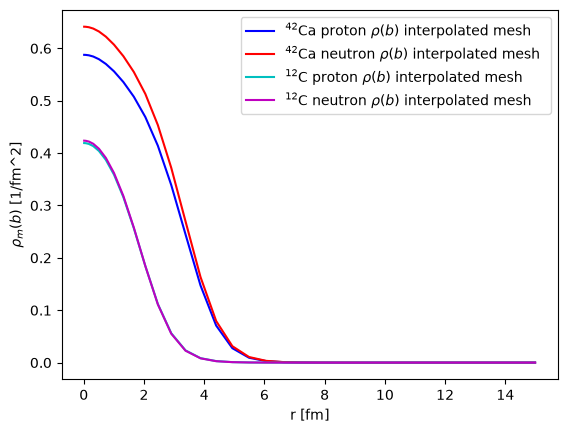

In [10]:
plt.plot(cross_section.s_mapped_roots,Ca_p_b, color ="blue", label = r"$^{42}$Ca proton $\rho(b)$ interpolated mesh " )
plt.plot(cross_section.s_mapped_roots,Ca_n_b, color ="red", label = r"$^{42}$Ca neutron $\rho(b)$ interpolated mesh " )

plt.plot(cross_section.t_mapped_roots,C_p_b, color ="c", label = r"$^{12}$C proton $\rho(b)$ interpolated mesh " )
plt.plot(cross_section.t_mapped_roots,C_n_b, color ="m", label = r"$^{12}$C neutron $\rho(b)$ interpolated mesh " )

plt.ylabel(r"$\rho_m(b)$ [1/fm^2]")
plt.xlabel("r [fm]")
plt.legend()
plt.show()

## 4) Reaction Cross Section for $^{42}\mathrm{Ca}$ + $^{12}\mathrm{C}$

To compute the **reaction cross section** $\sigma_R$ for a **$^{42}\mathrm{Ca}$ + $^{12}\mathrm{C}$** collision, we use ERICCa's `sigma_R_pn` method. We can compute the cross sections in the Optical Limit Approximation (OLA) and the Modified Optical Limit Approximation (MOL) (see textbook as  Structure and Reactions of Light Exotic Nuclei by Y. Suzuki, K. Yabana, R. G. Lovas, and K. Varga)

In [8]:
# %%
# --- Compute Reaction Cross Sections: $^{12}$C on $^{42}$Ca ---
# Using microscopic pn prescription with first sample densities (ρ(b))

# MOL model calculation
sigma_pn_MOL = cross_section.sigma_R_pn(
    Ca_p_b,    # Target ($^{42}$Ca) proton density ρ_p,t(b)
    Ca_n_b,    # Target ($^{42}$Ca) neutron density ρ_n,t(b)
    C_p_b,     # Projectile ($^{12}$C) proton density ρ_p,p(b)
    C_n_b,     # Projectile ($^{12}$C) neutron density ρ_n,p(b)
    Gamma_pp=profile_np.Gamma_pp,
    Gamma_pn=profile_np.Gamma_pn,
    Gamma_nn=profile_np.Gamma_pn,
    Model='MOL'
)

# OLA model calculation
sigma_pn_OLA = cross_section.sigma_R_pn(
    Ca_p_b,
    Ca_n_b,
    C_p_b,
    C_n_b,
    Gamma_pp=profile_np.Gamma_pp,
    Gamma_pn=profile_np.Gamma_pn,
    Gamma_nn=profile_np.Gamma_pn,
    Model='OLA'
)

# Print results
print('Reaction cross sections for $^{12}$C + $^{42}$Ca:')
print(f'  σ_R (pn, MOL) = {sigma_pn_MOL:.3f} mb')
print(f'  σ_R (pn, OLA) = {sigma_pn_OLA:.3f} mb')

Reaction cross sections for $^{12}$C + $^{42}$Ca:
  σ_R (pn, MOL) = 1514.857 mb
  σ_R (pn, OLA) = 1537.296 mb
